# Big Data in Finance: Part IV <BR><BR> Lecture Notes 2: CRSP 
    
**Instructor** <BR>
Kirsten Burr, kburr26@gsb.columbia.edu
    
**TA's:** <BR>
Luman Zou, lz2867@columbia.edu <BR>
Yifan Wan, YWan26@gsb.columbia.edu

<sub> Credit: lecture notes adapted from notes developed by Lira Mota

**Objectives:** <BR>
1. Download and understand the basics of CRSP tables:
    1. Stock Monthly Aggregate Security Data (StkMthSecurityData)
    2. Stock Security Information History (StkSecurityInfoHist)
    3. Risk free rates (IndMthSeriesData_Ind)

2. Create one data frame with the following variables:
    1. Stock exchange codes
    2. Security codes
    3. Stock monthly returns (including delisting returns)
    4. Market Equity Value (Number of shares * Price)
    5. Risk Free Rate

3. Add variables:
    1. Rankyear - Fama and French yearly rebalancing schedule
    2. ME by PERMCO
    3. ME lag (used for portfolios weights)
    4. Cumulative past 11 months returns (used to calculate momentum portfolios - homework 2)

## Set Up

In [11]:
%matplotlib inline 

# Packages 
import wrds
import time
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 6]

import time
from time import strptime, strftime

# Setups
pd.set_option("display.max_rows", 300) # max number or rows to be displayed 
pd.set_option("display.max_columns", None) # max number or columns to be displayed 
pd.set_option("display.max_colwidth", None)

In [12]:
# Set WRDS Connection
db = wrds.Connection(wrds_username='khardnett') # make sure to configure wrds connector before hand.   

Loading library list...
Done


## How is the CRSP data organized?

In [3]:
libs = db.list_libraries()
# Transform crsp_tables to a Pandas data frame to have a better display.
libs = pd.DataFrame({'libs':libs}).sort_values('libs').reset_index(drop=True) 
libs.head(100)

,libs
0,aha_sample
1,ahasamp
2,audit
3,audit_acct_os
4,audit_audit_comp
5,audit_common
6,audit_corp_legal
7,auditsmp
8,auditsmp_all
9,bank


In [4]:
libs.shape

(376, 1)

### All tables in CRSPQ

In [5]:
# crspq: CRSP quartely update
crsp_tables = db.list_tables(library="crspq") 
# crspm: CRSP monthly update - not included in our subscription

# Transform crsp_tables to a Pandas data frame to have a better display.
crsp_tables = pd.DataFrame({'tables':crsp_tables}).sort_values('tables').reset_index(drop=True)  
crsp_tables.head(200) 

,tables
0,acti
1,asia
2,asib
3,asic
4,asio
5,asix
6,bmdebt
7,bmheader
8,bmpaymts
9,bmquotes


In [6]:
crsp_tables.shape

(387, 1)

### Recent changes to the structure of the CRSP Stock database 
In July 2022 CRSP released a new Flat File Format 2.0 (CIZ) for the CRSP US Stock & Indexes Databases with new technologies and data structures in an effort to modernize their processes [(see here for more details)](https://wrds-www.wharton.upenn.edu/pages/data-announcements/changes-to-crsp-data/).
* CRSP fully transitioned to CIZ as of the January 2025 data release, replacing the Legacy (FIZ) and Flat File Format 1.0 (SIZ) formats.
    1. Monthly Stock Files (MSF) $\rightarrow$ Stock Monthly Aggregate Security Data (StkMthSecurityData)
    2. Monthly Stock Events (MSE) $\rightarrow$ Stock Security Information History (StkSecurityInfoHist)
    3. Risk free rates (MCTI) $\rightarrow$ Index Monthly Series Data (IndMthSeriesData_Ind)
* Data columns have been restructured and renamed, and new fields for flagging delists, distributions, and share codes have been added.
* In the Legacy (FIZ) format, monthly returns are month to month holding period returns with dividends reinvested at month-end. In the new Flat File Format (CIZ), monthly returns are compounded daily returns with dividends reinvested on their ex-dates.
* The December 2024 data (released in January 2025) was the last release of datasets produced in the legacy SIZ/FIZ formats.


#### Variables in the Legacy vs. new CIZ versions

#####  Monthly stock file (legacy version)

In [7]:
db.describe_table(library="crsp", table="msf")

Approximately 5153763 rows in crsp.msf.


,name,nullable,type,comment
0,cusip,True,VARCHAR(8),CUSIP Header
1,permno,True,INTEGER,PERMNO
2,permco,True,INTEGER,PERMCO
3,issuno,True,INTEGER,Nasdaq Issue Number
4,hexcd,True,SMALLINT,Exchange Code Header
5,hsiccd,True,INTEGER,Standard Industrial Classification Code Header
6,date,True,DATE,Date of Observation
7,bidlo,True,"NUMERIC(11, 5)",Bid or Low Price
8,askhi,True,"NUMERIC(11, 5)",Ask or High Price
9,prc,True,"NUMERIC(11, 5)",Price or Bid/Ask Average


##### Extra Identifiers: Names table (legacy version)

In [8]:
db.describe_table(library="crsp", table="stocknames")

Approximately 83280 rows in crsp.stocknames.


,name,nullable,type,comment
0,permno,True,INTEGER,PERMNO
1,namedt,True,DATE,None
2,nameenddt,True,DATE,None
3,shrcd,True,SMALLINT,Share Code as of Name Start Date
4,exchcd,True,SMALLINT,Exchange Code
5,siccd,True,INTEGER,SIC Code as of Name Start Date
6,ncusip,True,VARCHAR(8),CUSIP
7,ticker,True,VARCHAR(8),Ticker Symbol
8,comnam,True,VARCHAR(35),Company Name
9,shrcls,True,VARCHAR(4),Share Class as of Name Start Date


#####  Monthly stock file (new CIZ version)

In [9]:
db.describe_table(library="crsp", table="msf_v2")

Approximately 5240606 rows in crsp.msf_v2.


,name,nullable,type,comment
0,permno,True,INTEGER,PERMNO
1,hdrcusip,True,VARCHAR(8),Header CUSIP -8 Characters
2,permco,True,INTEGER,PERMCO
3,siccd,True,INTEGER,Sic Code
4,nasdissuno,True,INTEGER,Nasdaq Issue Number
5,yyyymm,True,INTEGER,YYYYMM - Monthly Calendar Period Key
6,mthcaldt,True,DATE,Monthly Calendar Date
7,mthcompflg,True,VARCHAR(1),Monthly Completeness Flag
8,mthcompsubflg,True,VARCHAR(2),Monthly Completeness Sub-Flag
9,mthprc,True,"NUMERIC(13, 6)",Monthly Price


##### Extra Identifiers: Names table (new CIZ version)

In [10]:
db.describe_table(library="crsp", table="stocknames_v2")

Approximately 84166 rows in crsp.stocknames_v2.


,name,nullable,type,comment
0,permno,True,INTEGER,PERMNO
1,permco,True,INTEGER,PERMCO
2,namedt,True,DATE,Security Information Start Date
3,nameenddt,True,DATE,Security Information End Date
4,securitybegdt,True,DATE,Begin Date of Stock Data
5,securityenddt,True,DATE,End Date of Stock Data
6,hdrcusip,True,VARCHAR(8),Header CUSIP -8 Characters
7,hdrcusip9,True,VARCHAR(9),Header CUSIP -9 Characters
8,cusip,True,VARCHAR(8),CUSIP
9,cusip9,True,VARCHAR(9),CUSIP9


### Tables of interest

We are going to focus on four tables:

1. **Stock Monthly Aggregate Security Data (StkMthSecurityData)**: contains the prices, capitalization, compounded returns, total volumes, and identifying information and is accessed by the CRSP unique security identifier, PERMNO and the monthly period identifier, YYYYMM.

2. **Stock Security Information History (StkSecurityInfoHist)**: contains all the information CRSP has about a security including ticker, CUSIP, and issuer information, and it is accessed by the CRSP unique Security identifier, PERMNO, and a date range, SecInfoStartDt and SecInfoEndDt.

3. **Stock Monthly Cumulative Adjustment Factors (StkMthCumulativeAdjFactor)**: contains variables used to adjust prices and shares for stock splits and other corporate actions

4. **Index Monthly Series Data (IndMthSeriesData_Ind)**: contains the index returns, levels, counts, and other information accessed by the unique CRSP index identifier, INDNO, and a monthly trading period, YYYYMM. We will use for risk free rates.

Nice overview can be found [here](https://wrds-www.wharton.upenn.edu/pages/support/manuals-and-overviews/crsp/stocks-and-indices/crsp-ciz-faq/) and [here](https://wrds-www.wharton.upenn.edu/pages/support/manuals-and-overviews/crsp/stocks-and-indices/overview-crsp-us-stock-database/).

In [11]:
file_table = db.raw_sql("""SELECT *
                           FROM crsp.metafileinfo""")
file_table.loc[file_table.filename.isin(['StkMthSecurityData','StkMthCumulativeAdjFactor','StkSecurityInfoHist','IndMthSeriesData']),
                ['filename','filedesc','filedef','filecategory','filerowfreq','filecolumncnt']].drop_duplicates()

,filename,filedesc,filedef,filecategory,filerowfreq,filecolumncnt
3,IndMthSeriesData,Index Monthly Series Data,"Index Monthly Series Data contains the index returns, levels, counts, and other information accessed by the unique CRSP index identifier, INDNO, and a monthly trading period, YYYYMM.",TIMESERIES,MONTHLY,15
27,StkMthCumulativeAdjFactor,Stock Monthly Cumulative Adjustment Factors,Stock Monthly Cumulative Adjustment Factors,TIMESERIES,MONTHLY,5
29,StkMthSecurityData,Stock Monthly Aggregate Security Data,"Stock Monthly Aggregate Security Data contains the prices, capitalization, compounded returns, total volumes, and identifying information and is accessed by the CRSP unique security identifier, PERMNO and the monthly period identifier, YYYYMM",TIMESERIES,MONTHLY,37
32,StkSecurityInfoHist,Stock Security Information History,"Stock Security Information History contains all the information CRSP has about a security including ticker, CUSIP, and issuer information, and it is accessed by the CRSP unique Security identifier, PERMNO, and a date range, SecInfoStartDt and SecInfoEndDt",IDENTIFIER,DATERANGE,36


## Which stock identifier to use?

* permno?
* permco?
* cusip?
* hdrcusip?
* ticker?
* securitynm?
* issuernm?

In [12]:
## An explample of name change
info_vars = ['permno', 'permco', 'secinfostartdt', 'secinfoenddt', 'securitybegdt',
             'securityenddt', 'cusip', 'hdrcusip',  'ticker','securitynm', 'issuernm',
             'shareclass','primaryexch', 'conditionaltype', 'tradingstatusflg', 
             'exchangetier','naics','icbindustry']

query = """SELECT {}
           FROM crsp.stksecurityinfohist""".format(', '.join(info_vars))
print(query)

SELECT permno, permco, secinfostartdt, secinfoenddt, securitybegdt, securityenddt, cusip, hdrcusip, ticker, securitynm, issuernm, shareclass, primaryexch, conditionaltype, tradingstatusflg, exchangetier, naics, icbindustry
           FROM crsp.stksecurityinfohist


In [13]:
info_table = db.raw_sql(query)
del(info_vars, query) 

In [14]:
# Google
# info_table[info_table.permno==14542]
info_table[(info_table.ticker=='GOOG')| (info_table.ticker=='GOOGL')].sort_values('secinfostartdt')

,permno,permco,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,cusip,hdrcusip,ticker,securitynm,issuernm,shareclass,primaryexch,conditionaltype,tradingstatusflg,exchangetier,naics,icbindustry
174438,90319,45483,2004-08-19,2005-08-18,2004-08-19,2025-12-31,38259P50,02079K30,GOOG,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,NMS,514191,NOAVAIL
174439,90319,45483,2005-08-19,2006-07-02,2004-08-19,2025-12-31,38259P50,02079K30,GOOG,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,NMS,518111,NOAVAIL
174440,90319,45483,2006-07-03,2006-07-20,2004-08-19,2025-12-31,38259P50,02079K30,GOOG,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,Q,518111,NOAVAIL
174441,90319,45483,2006-07-21,2008-01-31,2004-08-19,2025-12-31,38259P50,02079K30,GOOG,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,Q,518112,NOAVAIL
174442,90319,45483,2008-02-01,2008-06-26,2004-08-19,2025-12-31,38259P50,02079K30,GOOG,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,Q,519130,NOAVAIL
174443,90319,45483,2008-06-27,2014-04-02,2004-08-19,2025-12-31,38259P50,02079K30,GOOG,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,Q,519130,TECH
174444,90319,45483,2014-04-03,2015-04-23,2004-08-19,2025-12-31,38259P50,02079K30,GOOGL,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,Q,519130,TECH
21526,14542,45483,2014-04-03,2015-04-23,2014-04-03,2025-12-31,38259P70,02079K10,GOOG,GOOGLE INC; COM C; CONS,GOOGLE INC,C,Q,RW,A,Q,519130,TECH
21527,14542,45483,2015-04-24,2015-10-04,2014-04-03,2025-12-31,38259P70,02079K10,GOOG,GOOGLE INC; COM C; CONS,GOOGLE INC,C,Q,RW,A,Q,519190,TECH
174445,90319,45483,2015-04-24,2015-10-04,2004-08-19,2025-12-31,38259P50,02079K30,GOOGL,GOOGLE INC; COM A; CONS,GOOGLE INC,A,Q,RW,A,Q,519190,TECH


In [15]:
# Berkshire Hathaway
info_table[info_table.issuernm.str.contains('BERKSHIRE HATHAWAY')].sort_values('secinfostartdt')

,permno,permco,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,cusip,hdrcusip,ticker,securitynm,issuernm,shareclass,primaryexch,conditionaltype,tradingstatusflg,exchangetier,naics,icbindustry
34765,17778,540,1976-10-14,1982-10-31,1976-10-14,2025-12-31,08467010,08467010,BKHT,BERKSHIRE HATHAWAY INC DEL; COM NONE; CONS,BERKSHIRE HATHAWAY INC DEL,None,Q,RW,A,N/A,0,NOAVAIL
34766,17778,540,1982-11-01,1985-04-15,1976-10-14,2025-12-31,08467010,08467010,BKHT,BERKSHIRE HATHAWAY INC DEL; COM NONE; CONS,BERKSHIRE HATHAWAY INC DEL,None,Q,RW,A,SC1,0,NOAVAIL
34767,17778,540,1985-04-16,1986-03-31,1976-10-14,2025-12-31,08467010,08467010,BKHT,BERKSHIRE HATHAWAY INC DEL; COM NONE; CONS,BERKSHIRE HATHAWAY INC DEL,None,Q,RW,A,NMS,0,NOAVAIL
34768,17778,540,1986-04-01,1988-11-28,1976-10-14,2025-12-31,08467010,08467010,BKHT,BERKSHIRE HATHAWAY INC DEL; COM NONE; CONS,BERKSHIRE HATHAWAY INC DEL,None,Q,RW,A,NMS,0,NOAVAIL
34769,17778,540,1988-11-29,1996-05-08,1976-10-14,2025-12-31,08467010,08467010,BRK,BERKSHIRE HATHAWAY INC DEL; COM NONE; CONS,BERKSHIRE HATHAWAY INC DEL,None,N,RW,A,N/A,0,NOAVAIL
34770,17778,540,1996-05-09,2002-01-01,1976-10-14,2025-12-31,08467010,08467010,BRK,BERKSHIRE HATHAWAY INC DEL; COM A; CONS,BERKSHIRE HATHAWAY INC DEL,A,N,RW,A,N/A,0,NOAVAIL
142755,83443,540,1996-05-09,2002-01-01,1996-05-09,2025-12-31,08467020,08467070,BRK,BERKSHIRE HATHAWAY INC DEL; COM B; CONS,BERKSHIRE HATHAWAY INC DEL,B,N,RW,A,N/A,0,NOAVAIL
34771,17778,540,2002-01-02,2004-06-09,1976-10-14,2025-12-31,08467010,08467010,BRK,BERKSHIRE HATHAWAY INC DEL; COM A; CONS,BERKSHIRE HATHAWAY INC DEL,A,N,RW,A,N/A,0,NOAVAIL
142756,83443,540,2002-01-02,2004-06-09,1996-05-09,2025-12-31,08467020,08467070,BRK,BERKSHIRE HATHAWAY INC DEL; COM B; CONS,BERKSHIRE HATHAWAY INC DEL,B,N,RW,A,N/A,0,NOAVAIL
34772,17778,540,2004-06-10,2009-03-26,1976-10-14,2025-12-31,08467010,08467010,BRK,BERKSHIRE HATHAWAY INC DEL; COM A; CONS,BERKSHIRE HATHAWAY INC DEL,A,N,RW,A,N/A,524126,NOAVAIL


In [16]:
# One permco, multiple permno, multiple cusip

# AT&T
info_table[info_table.permco==20103]

,permno,permco,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,cusip,hdrcusip,ticker,securitynm,issuernm,shareclass,primaryexch,conditionaltype,tradingstatusflg,exchangetier,naics,icbindustry
2286,10401,20103,1925-12-31,1962-07-01,1925-12-31,2005-11-18,None,00195750,None,AMERICAN TELEPHONE & TELEG CO; COM NONE; CONS,AMERICAN TELEPHONE & TELEG CO,None,N,RW,A,N/A,0,NOAVAIL
2287,10401,20103,1962-07-02,1968-01-01,1925-12-31,2005-11-18,None,00195750,T,AMERICAN TELEPHONE & TELEG CO; COM NONE; CONS,AMERICAN TELEPHONE & TELEG CO,None,N,RW,A,N/A,0,NOAVAIL
2288,10401,20103,1968-01-02,1994-04-20,1925-12-31,2005-11-18,03017710,00195750,T,AMERICAN TELEPHONE & TELEG CO; COM NONE; CONS,AMERICAN TELEPHONE & TELEG CO,None,N,RW,A,N/A,0,NOAVAIL
2289,10401,20103,1994-04-21,2001-02-28,1925-12-31,2005-11-18,00195710,00195750,T,A T & T CORP; COM NONE; CONS,A T & T CORP,None,N,RW,A,N/A,0,NOAVAIL
2290,10401,20103,2001-03-01,2002-01-01,1925-12-31,2005-11-18,00195710,00195750,T,A T & T CORP; COM NONE; CONS,A T & T CORP,None,N,RW,A,N/A,0,NOAVAIL
2291,10401,20103,2002-01-02,2002-11-18,1925-12-31,2005-11-18,00195710,00195750,T,A T & T CORP; COM NONE; CONS,A T & T CORP,None,N,RW,A,N/A,0,NOAVAIL
2292,10401,20103,2002-11-19,2004-06-09,1925-12-31,2005-11-18,00195750,00195750,T,A T & T CORP; COM NONE; CONS,A T & T CORP,None,N,RW,A,N/A,0,NOAVAIL
2293,10401,20103,2004-06-10,2005-10-23,1925-12-31,2005-11-18,00195750,00195750,T,A T & T CORP; COM NONE; CONS,A T & T CORP,None,N,RW,A,N/A,513322,NOAVAIL
2294,10401,20103,2005-10-24,2005-11-18,1925-12-31,2005-11-18,00195750,00195750,T,A T & T CORP; COM NONE; CONS,A T & T CORP,None,N,RW,A,N/A,517212,NOAVAIL
2295,10401,20103,2005-11-19,2005-11-21,1925-12-31,2005-11-18,None,00195750,None,A T & T CORP (LAST KNOWN); COM NONE; CONS,A T & T CORP (Last Known),None,X,N/A,D,N/A,0,NOAVAIL


### Primary Keys (PK)

* Company identifier: PERMCO
* Security identifier: PERMNO
* Date: monthly or daily

## The Monthly Time Series Security Data table

### All variables

In [13]:
db.describe_table(library="crsp", table="stkmthsecuritydata")

Approximately 5240606 rows in crsp.stkmthsecuritydata.


,name,nullable,type,comment
0,permno,True,INTEGER,PERMNO
1,yyyymm,True,INTEGER,YYYYMM - Monthly Calendar Period Key
2,mthcaldt,True,DATE,Monthly Calendar Date
3,mthcompflg,True,VARCHAR(1),Monthly Completeness Flag
4,mthcompsubflg,True,VARCHAR(2),Monthly Completeness Sub-Flag
5,mthprc,True,"NUMERIC(13, 6)",Monthly Price
6,mthprcflg,True,VARCHAR(2),Monthly Price Flag
7,mthprcdt,True,DATE,Monthly Price Date
8,mthdtflg,True,VARCHAR(2),Monthly Price Date Flag
9,mthdelflg,True,VARCHAR(1),Monthly Delisting Flag


### Variables of interest

1. Identifiers: mthcaldt, permno
2. Price: mthprc
    1. Price flag: [mthprcflg](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stkmthsecuritydata/mthprcflg/) 
    2. Price date: mthprcdt
    3. Date flag: [mthdtflg](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stkmthsecuritydata/mthdtflg/) 
4. Return: mthret
5. Return ex-dividend: mthretx
6. Delisting return flag: [mthdelflg](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stkmthsecuritydata/mthdelflg/) 

Where to find variable definitions? [WRDS website](https://wrds-www.wharton.upenn.edu/documents/1996/CRSP_US_Stock__Indexes_Database_Guide_Flat_File_Format_2.0.pdf).


In [18]:
mts_vars = ['mthprc','mthprcflg','mthprcdt','mthdtflg','mthret', 'mthretx','mthdelflg','mthvol']
query = """SELECT mthcaldt, permno, {} 
           FROM crsp.stkmthsecuritydata
           WHERE mthcaldt>='1980-01-01'""".format(', '.join(mts_vars))
print(query)

SELECT mthcaldt, permno, mthprc, mthprcflg, mthprcdt, mthdtflg, mthret, mthretx, mthdelflg, mthvol 
           FROM crsp.stkmthsecuritydata
           WHERE mthcaldt>='1980-01-01'


In [19]:
toc = time.time()

mts_data = db.raw_sql(query, date_cols=['mthcaldt'])
del(mts_vars, query) 

tic = time.time()
print(tic-toc)

32.95535206794739


**Look at the data**

In [20]:
mts_data.sort_values(['mthcaldt','permno']).head()

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol
916,1980-01-31,10006,41.500,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0
7682,1980-01-31,10057,33.500,TR,1980-01-31,PE,0.282297,0.282297,N,196500.0
7881,1980-01-31,10058,2.500,BA,1980-01-31,PE,0.000000,0.000000,N,NaN
8628,1980-01-31,10065,12.875,TR,1980-01-31,PE,0.099216,0.061569,N,222100.0
13518,1980-01-31,10103,1.625,BA,1980-01-31,PE,0.083333,0.083333,N,NaN


In [21]:
# Check if we have a primary key
mts_data.duplicated(subset=['permno', 'mthcaldt']).sum()

0

<Axes: title={'center': 'Cumulative Returns of Apple'}, xlabel='mthcaldt'>

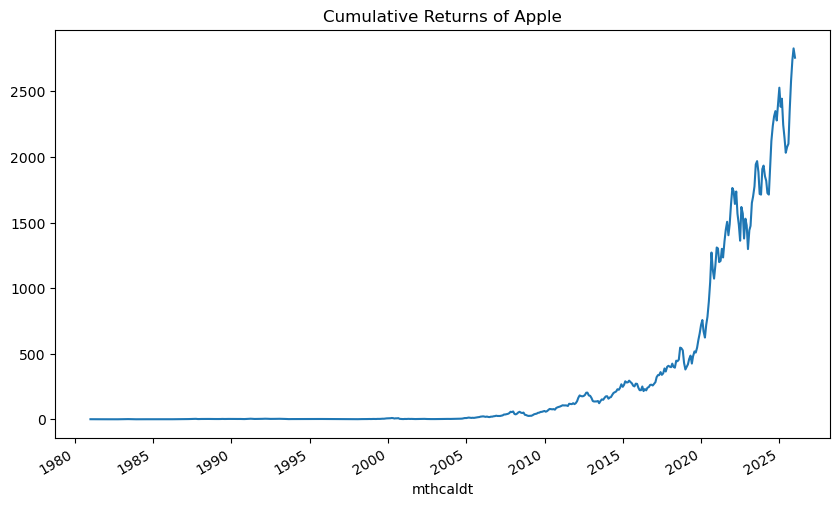

In [22]:
# Cumulative returns of Apple 
apple_ret = mts_data[mts_data.permno==14593].set_index(['mthcaldt']).mthret
((1+apple_ret).cumprod()).plot(title='Cumulative Returns of Apple')  

<Axes: title={'center': 'Cumulative Returns of Apple'}, xlabel='mthcaldt'>

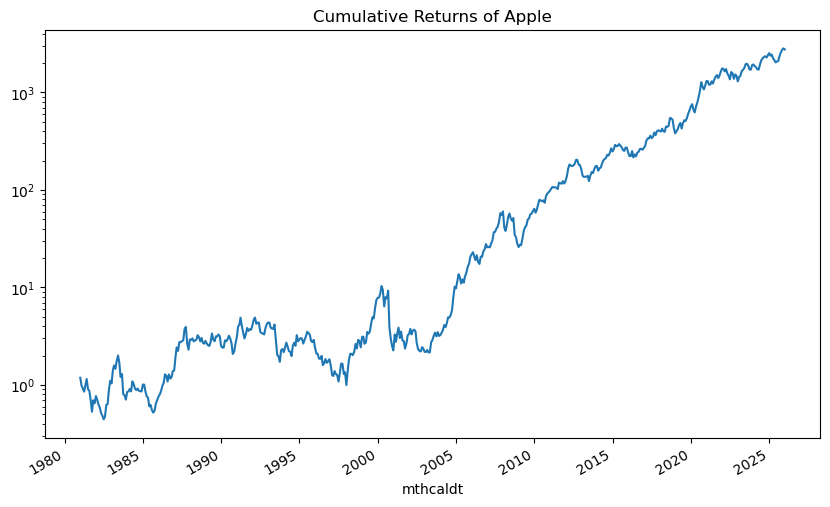

In [23]:
# Cumulative returns of Apple 
apple_ret = mts_data[mts_data.permno==14593].set_index(['mthcaldt']).mthret
((1+apple_ret).cumprod()).plot(title='Cumulative Returns of Apple', logy=True)  

## The Monthly Cumulative Adjustment Factor table

### All variables

In [24]:
db.describe_table(library="crsp", table="stkmthcumulativeadjfactor")

Approximately 5209205 rows in crsp.stkmthcumulativeadjfactor.


,name,nullable,type,comment
0,permno,True,INTEGER,PERMNO
1,mthcaldt,True,DATE,Monthly Calendar Date
2,mthshrout,True,"NUMERIC(14, 0)",Monthly Total Shares Outstanding
3,mthcumfacpr,True,"NUMERIC(17, 12)",Monthly Cumulative Factor to Adjust Price
4,mthcumfacshr,True,"NUMERIC(17, 12)",Monthly Cumulative Factor to Adjust Shares


### Variables of interest

1. Identifiers: mthcaldt, permno
2. Shares outstanding (in thousands, unadjusted for splits): mthshrout
3. Factor to adjust prices and shares outstanding after splits and distributions: mthcumfacpr/mthcumfacshr

Where to find variable definitions? [WRDS website](https://wrds-www.wharton.upenn.edu/documents/1996/CRSP_US_Stock__Indexes_Database_Guide_Flat_File_Format_2.0.pdf).


In [25]:
query = """SELECT *
           FROM crsp.stkmthcumulativeadjfactor
           WHERE mthcaldt>='1980-01-01'"""
print(query)

SELECT *
           FROM crsp.stkmthcumulativeadjfactor
           WHERE mthcaldt>='1980-01-01'


In [26]:
shr_data = db.raw_sql(query, date_cols=['mthcaldt'])
del(query) 

**Look at the data**

In [27]:
shr_data.sort_values(['mthcaldt','permno']).head()

,permno,mthcaldt,mthshrout,mthcumfacpr,mthcumfacshr
906,10006,1980-01-31,8859.0,1.0,1.0
7629,10057,1980-01-31,4251.0,1.0,1.0
7827,10058,1980-01-31,1251.0,1.0,1.0
8567,10065,1980-01-31,15624.0,1.5,1.5
13432,10103,1980-01-31,1362.0,1.0,1.0


### Merge Monthly Time Series Security Data and Monthly Cumulative Adjustment Factor tables
Add cumulative adjustment factors and shares outstanding to the main monthly time series dataframe.

When merging, check data types. Merge does not work for PERMNO as float.

In [28]:
mts_data.dtypes

mthcaldt     datetime64[ns]
permno                int64
mthprc              float64
mthprcflg            object
mthprcdt             object
mthdtflg             object
mthret              float64
mthretx             float64
mthdelflg            object
mthvol              float64
dtype: object

In [29]:
## Check data types
shr_data.dtypes       

permno                   int64
mthcaldt        datetime64[ns]
mthshrout              float64
mthcumfacpr            float64
mthcumfacshr           float64
dtype: object

In [30]:
# Change Permno Data Type.
mts_data['permno'] = mts_data['permno'].astype('int')
shr_data['permno'] = shr_data['permno'].astype('int')

In [31]:
mts_data.sort_values(['mthcaldt', 'permno'], inplace=True)
shr_data.sort_values(['mthcaldt', 'permno'], inplace=True)

In [32]:
crsp_ts_data = mts_data.merge(shr_data,how='left',on=['permno', 'mthcaldt'])
crsp_ts_data.head()

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,mthshrout,mthcumfacpr,mthcumfacshr
0,1980-01-31,10006,41.500,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0,8859.0,1.0,1.0
1,1980-01-31,10057,33.500,TR,1980-01-31,PE,0.282297,0.282297,N,196500.0,4251.0,1.0,1.0
2,1980-01-31,10058,2.500,BA,1980-01-31,PE,0.000000,0.000000,N,NaN,1251.0,1.0,1.0
3,1980-01-31,10065,12.875,TR,1980-01-31,PE,0.099216,0.061569,N,222100.0,15624.0,1.5,1.5
4,1980-01-31,10103,1.625,BA,1980-01-31,PE,0.083333,0.083333,N,NaN,1362.0,1.0,1.0


In [33]:
del mts_data,shr_data 

## The Stock Security Information History table

### All variables

In [34]:
db.describe_table(library="crsp", table="stksecurityinfohist")

Approximately 190040 rows in crsp.stksecurityinfohist.


,name,nullable,type,comment
0,permno,True,INTEGER,PERMNO
1,secinfostartdt,True,DATE,Security Information Start Date
2,secinfoenddt,True,DATE,Security Information End Date
3,securitybegdt,True,DATE,Begin Date of Stock Data
4,securityenddt,True,DATE,End Date of Stock Data
5,securityhdrflg,True,VARCHAR(1),Security Header Flag
6,hdrcusip,True,VARCHAR(8),Header CUSIP -8 Characters
7,hdrcusip9,True,VARCHAR(9),Header CUSIP -9 Characters
8,cusip,True,VARCHAR(8),CUSIP
9,cusip9,True,VARCHAR(9),CUSIP9


### Variables of Interest 
1. Primary dentifiers: permno, secinfostartdt, secinfoenddt
2. Other identifiers: permco, cusip, ticker, securitynm, issuernm
3. Exchange codes: usually we only look at shares trading on the NYSE, NYSE American, and NASDAQ
    1. Primary exchange: [primaryexch](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/primaryexch/) 
    2. Conditional type (e.g. when-issued, regular way, etc.): [conditionaltype](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/conditionaltype/) 
    3. Trading status (Active, Halt, Suspend): [tradingstatusflg](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/tradingstatusflg/) 
4. Share Type codes: usually we only look at ordinary common shares
   1. Share class: [shareclass](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/shareclass/)
   2. Share type (Com, Adrs, Sbis, Etc.): [sharetype](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/sharetype/) 
   3. Security type (Fund, Equity, Unit, Etc.): [securitytype](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/securitytype/) 
   4. Security sub-type (Com, Etn, Etf,Etc.): [securitysubtype](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/securitysubtype/) 
   5. US Incorporation Flag - is the Issuer incorporated within the US (Y = Yes, N = No, X = unknown or not applicable): [usincflg](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/usincflg/) 
   6. Issuer type (Corp, Ltd, Reit, Etc.): [issuertype](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stksecurityinfohist/issuertype/) 
6. Industry classifications: siccd, naics


In [35]:
info_vars = ['permno','secinfostartdt', 'secinfoenddt', 'securitybegdt','securityenddt',
              'permco', 'cusip', 'hdrcusip',  'ticker','securitynm', 'issuernm',
              'primaryexch', 'conditionaltype', 'tradingstatusflg', 
              'shareclass','sharetype', 'securitytype', 'securitysubtype','usincflg','issuertype',
              'siccd','naics']

query = """SELECT {}
           FROM crsp.stksecurityinfohist
           WHERE securityenddt>'1980-01-01'""".format(', '.join(info_vars))
print(query)

SELECT permno, secinfostartdt, secinfoenddt, securitybegdt, securityenddt, permco, cusip, hdrcusip, ticker, securitynm, issuernm, primaryexch, conditionaltype, tradingstatusflg, shareclass, sharetype, securitytype, securitysubtype, usincflg, issuertype, siccd, naics
           FROM crsp.stksecurityinfohist
           WHERE securityenddt>'1980-01-01'


In [36]:
info_data = db.raw_sql(query, date_cols=['secinfostartdt', 'secinfoenddt', 'securitybegdt','securityenddt'])
del(info_vars, query)  

**Look at the data...**

In [37]:
info_data[info_data.permno==14593]  

,permno,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,permco,cusip,hdrcusip,ticker,securitynm,issuernm,primaryexch,conditionaltype,tradingstatusflg,shareclass,sharetype,securitytype,securitysubtype,usincflg,issuertype,siccd,naics
20768,14593,1980-12-12,1982-03-31,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE COMPUTER INC; COM NONE; CONS,APPLE COMPUTER INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3573,0
20769,14593,1982-04-01,1982-10-31,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE COMPUTER INC; COM NONE; CONS,APPLE COMPUTER INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3573,0
20770,14593,1982-11-01,2004-06-09,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE COMPUTER INC; COM NONE; CONS,APPLE COMPUTER INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3573,0
20771,14593,2004-06-10,2006-07-02,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE COMPUTER INC; COM NONE; CONS,APPLE COMPUTER INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3573,334111
20772,14593,2006-07-03,2007-01-10,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE COMPUTER INC; COM NONE; CONS,APPLE COMPUTER INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3573,334111
20773,14593,2007-01-11,2009-03-26,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE INC; COM NONE; CONS,APPLE INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3571,334111
20774,14593,2009-03-27,2017-12-27,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE INC; COM NONE; CONS,APPLE INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3571,334111
20775,14593,2017-12-28,2021-12-08,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE INC; COM NONE; CONS,APPLE INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3571,334220
20776,14593,2021-12-09,2023-09-28,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE INC; COM NONE; CONS,APPLE INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3663,334220
20777,14593,2023-09-29,2023-09-30,1980-12-12,2025-12-31,7,03783310,03783310,AAPL,APPLE INC; COM NONE; CONS,APPLE INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,3663,334220


## Merge Stock Information History data with other CRSP time series variables

When merging, check data types. Merge does not work for PERMNO as float.

In [38]:
# Check data types
info_data.dtypes

permno                       int64
secinfostartdt      datetime64[ns]
secinfoenddt        datetime64[ns]
securitybegdt       datetime64[ns]
securityenddt       datetime64[ns]
permco                       int64
cusip                       object
hdrcusip                    object
ticker                      object
securitynm                  object
issuernm                    object
primaryexch                 object
conditionaltype             object
tradingstatusflg            object
shareclass                  object
sharetype                   object
securitytype                object
securitysubtype             object
usincflg                    object
issuertype                  object
siccd                        int64
naics                       object
dtype: object

In [39]:
# Check data types
crsp_ts_data.dtypes       

mthcaldt        datetime64[ns]
permno                   int64
mthprc                 float64
mthprcflg               object
mthprcdt                object
mthdtflg                object
mthret                 float64
mthretx                float64
mthdelflg               object
mthvol                 float64
mthshrout              float64
mthcumfacpr            float64
mthcumfacshr           float64
dtype: object

In [40]:
# Change Permno Data Type
info_data['permno'] = info_data['permno'].astype('int')
crsp_ts_data['permno'] = crsp_ts_data['permno'].astype('int')

In [41]:
info_data.sort_values(['secinfostartdt', 'permno'], inplace=True)
crsp_ts_data.sort_values(['mthcaldt', 'permno'], inplace=True)

In [42]:
# Check of coverage
x = pd.Series(crsp_ts_data.permno.unique())
y = pd.Series(info_data.permno.unique())

In [43]:
# Have price but no info?
x[~x.isin(y)]

Series([], dtype: int64)

In [44]:
# Have info but no price?
y[~y.isin(x)]

Series([], dtype: int64)

In [45]:
# Change the last security information end date to N/A in order to complete the merger
info_data.loc[info_data.groupby('permno').secinfoenddt.idxmax(), 'secinfoenddt'] = np.nan

**Merge tables with following logic:** 
* For each permno-date observation in the time series table, keep the info table observation with same permno where the time series date is within info date range.

In [46]:
# Merge 
crsp_data = pd.merge(crsp_ts_data, info_data, on=['permno'], how='inner') 
crsp_data.head()

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,mthshrout,mthcumfacpr,mthcumfacshr,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,permco,cusip,hdrcusip,ticker,securitynm,issuernm,primaryexch,conditionaltype,tradingstatusflg,shareclass,sharetype,securitytype,securitysubtype,usincflg,issuertype,siccd,naics
0,1980-01-31,10006,41.5,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0,8859.0,1.0,1.0,1925-12-31,1954-05-31,1925-12-31,1984-06-28,22156,None,00080010,None,AMERICAN CAR & FDRY CO; COM NONE; CONS,AMERICAN CAR & FDRY CO,N,RW,A,None,NS,EQTY,COM,Y,ACOR,3740,0
1,1980-01-31,10006,41.5,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0,8859.0,1.0,1.0,1954-06-01,1962-07-01,1925-12-31,1984-06-28,22156,None,00080010,None,A C F INDUSTRIES INC; COM NONE; CONS,A C F INDUSTRIES INC,N,RW,A,None,NS,EQTY,COM,Y,ACOR,3740,0
2,1980-01-31,10006,41.5,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0,8859.0,1.0,1.0,1962-07-02,1968-01-01,1925-12-31,1984-06-28,22156,None,00080010,ACF,A C F INDUSTRIES INC; COM NONE; CONS,A C F INDUSTRIES INC,N,RW,A,None,NS,EQTY,COM,Y,ACOR,3743,0
3,1980-01-31,10006,41.5,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0,8859.0,1.0,1.0,1968-01-02,1984-06-28,1925-12-31,1984-06-28,22156,00080010,00080010,ACF,A C F INDUSTRIES INC; COM NONE; CONS,A C F INDUSTRIES INC,N,RW,A,None,NS,EQTY,COM,Y,ACOR,3743,0
4,1980-01-31,10006,41.5,TR,1980-01-31,PE,0.211679,0.211679,N,590300.0,8859.0,1.0,1.0,1984-06-29,NaT,1925-12-31,1984-06-28,22156,None,00080010,None,A C F INDUSTRIES INC (LAST KNOWN); COM NONE; CONS,A C F INDUSTRIES INC (Last Known),X,N/A,D,None,N/A,N/A,UNK,N,ACOR,0,0


In [47]:
# Check number of observations pre- and post-merge
print(crsp_ts_data.shape)
print(crsp_data.shape)

(4121729, 13)
(30606047, 34)


In [48]:
# Keep only link in the right range
crsp_data = crsp_data[(crsp_data.mthcaldt >= crsp_data.secinfostartdt)]
crsp_data = crsp_data[(crsp_data.mthcaldt <= crsp_data.secinfoenddt) | (crsp_data.secinfoenddt.isnull()) ]

In [49]:
# Check number of observations pre- and post-merge
print(crsp_ts_data.shape)
print(crsp_data.shape)

(4121729, 13)
(4121729, 34)


In [50]:
crsp_data['permno'] = crsp_data['permno'].astype(int)
crsp_data['permco'] = crsp_data['permco'].astype(int)
crsp_data['mthcaldt'] = pd.to_datetime(crsp_data['mthcaldt'])
crsp_data

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,mthshrout,mthcumfacpr,mthcumfacshr,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,permco,cusip,hdrcusip,ticker,securitynm,issuernm,primaryexch,conditionaltype,tradingstatusflg,shareclass,sharetype,securitytype,securitysubtype,usincflg,issuertype,siccd,naics
3,1980-01-31,10006,41.500,TR,1980-01-31,PE,0.211679,0.211679,N,5.903000e+05,8859.0,1.0,1.0,1968-01-02,1984-06-28,1925-12-31,1984-06-28,22156,00080010,00080010,ACF,A C F INDUSTRIES INC; COM NONE; CONS,A C F INDUSTRIES INC,N,RW,A,None,NS,EQTY,COM,Y,ACOR,3743,0
7,1980-01-31,10057,33.500,TR,1980-01-31,PE,0.282297,0.282297,N,1.965000e+05,4251.0,1.0,1.0,1968-10-28,1991-09-30,1925-12-31,1996-07-02,20020,00462610,00462610,AMT,ACME CLEVELAND CORP; COM NONE; CONS,ACME CLEVELAND CORP,N,RW,A,None,NS,EQTY,COM,Y,CORP,3541,0
12,1980-01-31,10058,2.500,BA,1980-01-31,PE,0.000000,0.000000,N,NaN,1251.0,1.0,1.0,1975-01-24,1982-10-31,1972-12-14,1984-09-11,20,00077410,00077410,ABKC,A B K C O INDUSTRIES INC; COM NONE; CONS,A B K C O INDUSTRIES INC,Q,RW,A,None,NS,EQTY,COM,Y,ACOR,5099,0
18,1980-01-31,10065,12.875,TR,1980-01-31,PE,0.099216,0.061569,N,2.221000e+05,15624.0,1.5,1.5,1968-01-02,2001-08-23,1925-12-31,2025-12-31,20023,00621210,00621210,ADX,ADAMS EXPRESS CO; CEFNONE; CONS,ADAMS EXPRESS CO,N,RW,A,None,NS,FUND,CEF,Y,ACOR,6723,0
26,1980-01-31,10103,1.625,BA,1980-01-31,PE,0.083333,0.083333,N,NaN,1362.0,1.0,1.0,1977-03-23,1982-10-31,1977-03-23,1989-12-27,52,00087410,00087410,ACSC,A C S INDUSTRIES INC; COM NONE; CONS,A C S INDUSTRIES INC,Q,RW,A,None,NS,EQTY,COM,Y,ACOR,3496,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30606020,2025-12-31,93425,28.320,TR,2025-12-31,PE,-0.029140,-0.029140,N,8.667577e+06,3500.0,1.0,1.0,2023-10-01,NaT,2010-06-02,2025-12-31,53442,91167Q10,91167Q10,BNO,UNITED STATES BRENT OIL FUND LP; ETFNONE; CONS,UNITED STATES BRENT OIL FUND LP,R,RW,A,None,NS,FUND,ETF,Y,ACOR,6726,525990
30606024,2025-12-31,93426,38.500,TR,2025-12-31,PE,0.127709,0.127709,N,2.918693e+06,12256.0,1.0,1.0,2023-10-01,NaT,2010-07-07,2025-12-31,53443,92835K10,92835K10,VPG,VISHAY PRECISION GROUP INC; COM NONE; CONS,VISHAY PRECISION GROUP INC,N,RW,A,None,NS,EQTY,COM,Y,CORP,3676,334416
30606031,2025-12-31,93427,455.280,TR,2025-12-31,PE,-0.008990,-0.008990,N,1.134708e+07,35827.0,1.0,1.0,2024-06-20,NaT,2010-06-25,2025-12-31,53445,G3323L10,G3323L10,FN,FABRINET; COM NONE; CONS,FABRINET,N,RW,A,None,NS,EQTY,COM,N,CORP,3826,334516
30606041,2025-12-31,93429,251.000,TR,2025-12-31,PE,-0.027772,-0.027772,N,1.389963e+07,104645.0,1.0,1.0,2024-06-21,NaT,2010-06-15,2025-12-31,53447,12503M10,12503M10,CBOE,C B O E GLOBAL MARKETS INC; COM NONE; CONS,C B O E GLOBAL MARKETS INC,B,RW,A,None,NS,EQTY,COM,Y,CORP,6211,523150


In [51]:
del crsp_ts_data,info_data 

## Examine the merged CRSP dataset

### Check Primary Key

In [52]:
# Check PK
crsp_data.duplicated(subset=['mthcaldt','permno']).sum()

0

In [53]:
crsp_data.groupby(['permco', 'mthcaldt']).permno.nunique().mean()  

1.1217909009754399

In [54]:
crsp_data.groupby(['permco', 'mthcaldt']).permno.nunique().max() 

362

### Check delisting returns included at end of return time series

In [55]:
# Returns adjusted for delisting
crsp_data[(crsp_data.permno==10002) & (crsp_data.mthcaldt.dt.year>=2012)]

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,mthshrout,mthcumfacpr,mthcumfacshr,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,permco,cusip,hdrcusip,ticker,securitynm,issuernm,primaryexch,conditionaltype,tradingstatusflg,shareclass,sharetype,securitytype,securitysubtype,usincflg,issuertype,siccd,naics
20729534,2012-01-31,10002,1.2800,TR,2012-01-31,PE,0.032258,0.032258,N,253561.0,17968.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
20786677,2012-02-29,10002,1.3000,TR,2012-02-29,PE,0.015625,0.015625,N,536293.0,17968.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
20843893,2012-03-30,10002,1.4500,TR,2012-03-30,PE,0.115385,0.115385,N,676133.0,17954.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
20901072,2012-04-30,10002,2.0800,TR,2012-04-30,PE,0.434483,0.434483,N,401688.0,17968.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
20958272,2012-05-31,10002,2.9400,TR,2012-05-31,PE,0.413462,0.413462,N,1694974.0,17968.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
21015473,2012-06-29,10002,2.9900,TR,2012-06-29,PE,0.017007,0.017007,N,914407.0,17960.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
21072641,2012-07-31,10002,2.9600,TR,2012-07-31,PE,-0.010033,-0.010033,N,586574.0,17960.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
21129753,2012-08-31,10002,2.9000,TR,2012-08-31,PE,-0.020270,-0.020270,N,249456.0,17967.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
21186712,2012-09-28,10002,2.9800,TR,2012-09-28,PE,0.027586,0.027586,N,351123.0,17961.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111
21243459,2012-10-31,10002,2.8500,TR,2012-10-31,PE,-0.043624,-0.043624,N,318185.0,17961.0,1.0,1.0,2008-06-27,2013-02-15,1986-01-10,2013-02-15,7954,05978R10,05978R10,BTFG,BANCTRUST FINANCIAL GROUP INC; COM NONE; CONS,BANCTRUST FINANCIAL GROUP INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6020,551111


### Check types of prices recorded
*  Price flag: [mthprcflg](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_stock/stkmthsecuritydata/mthprcflg/)
    *  Most values are BA (Bid/Ask Average) or TR (Closing Trade).
* If the closing price is not available for any given period, the number in the price field is replaced with a bid/ask average. 
* If neither the price nor bid/ask average is available, the field is set to N/A.


In [56]:
# crsp_data[crsp_data.mthprcflg=='BA']
crsp_data[crsp_data.permno == 93368]

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,mthshrout,mthcumfacpr,mthcumfacshr,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,permco,cusip,hdrcusip,ticker,securitynm,issuernm,primaryexch,conditionaltype,tradingstatusflg,shareclass,sharetype,securitytype,securitysubtype,usincflg,issuertype,siccd,naics
19571791,2010-04-30,93368,10.4200,TR,2010-04-30,PE,-0.005911,-0.012322,N,1008336.0,4083.0,1.0,1.0,2010-04-05,2010-05-02,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19630098,2010-05-28,93368,10.0500,TR,2010-05-28,PE,-0.035509,-0.035509,N,244409.0,4083.0,1.0,1.0,2010-05-03,2010-06-24,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19688267,2010-06-30,93368,9.7500,TR,2010-06-30,PE,-0.029851,-0.029851,N,93384.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19746637,2010-07-30,93368,9.7200,TR,2010-07-30,PE,-0.003077,-0.003077,N,99321.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19804794,2010-08-31,93368,9.2000,TR,2010-08-31,PE,-0.046646,-0.053498,N,91765.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19862909,2010-09-30,93368,9.1000,TR,2010-09-30,PE,-0.010870,-0.010870,N,111264.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19920974,2010-10-29,93368,9.7000,TR,2010-10-29,PE,0.065934,0.065934,N,57482.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
19979039,2010-11-30,93368,10.0000,TR,2010-11-30,PE,0.038152,0.030928,N,36949.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
20037059,2010-12-31,93368,10.8300,TR,2010-12-31,PE,0.083000,0.083000,N,108690.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110
20094928,2011-01-31,93368,11.2500,TR,2011-01-31,PE,0.038781,0.038781,N,66070.0,4083.0,1.0,1.0,2010-06-25,2019-09-16,2010-04-05,2025-12-31,53402,26942G10,26942G10,EBMT,EAGLE BANCORP MONTANA INC; COM NONE; CONS,EAGLE BANCORP MONTANA INC,Q,RW,A,None,NS,EQTY,COM,Y,CORP,6710,522110


## Calculate Variables of Interest

In [57]:
crsp_data.columns

Index(['mthcaldt', 'permno', 'mthprc', 'mthprcflg', 'mthprcdt', 'mthdtflg',
       'mthret', 'mthretx', 'mthdelflg', 'mthvol', 'mthshrout', 'mthcumfacpr',
       'mthcumfacshr', 'secinfostartdt', 'secinfoenddt', 'securitybegdt',
       'securityenddt', 'permco', 'cusip', 'hdrcusip', 'ticker', 'securitynm',
       'issuernm', 'primaryexch', 'conditionaltype', 'tradingstatusflg',
       'shareclass', 'sharetype', 'securitytype', 'securitysubtype',
       'usincflg', 'issuertype', 'siccd', 'naics'],
      dtype='object')

### Calculate Market Equity (ME)

In [58]:
# SHROUT is the number of publicly held shares, recorded in thousands. ME will be reported in 1,000,000 ($10^6$),
# Like on Ken French's website. 
crsp_data['me'] = crsp_data['mthprc'] * (crsp_data['mthshrout']/1000)

In [59]:
# Also, some companies have multiple shareclasses (=PERMNOs).
# To get the company ME, we need to calculate the sum of ME over all shareclasses for one company (=PERMCO).
# This is used for sorting, but not for weights.

# Create MEsum
crsp_data['mesum'] = crsp_data.groupby(['mthcaldt', 'permco']).me.transform("sum", min_count=1)

In [60]:
# If the stock is delisted, we set ME to NaN.
crsp_data.loc[crsp_data.mthdelflg!='N', 'me'] = np.nan
crsp_data.loc[crsp_data.mthdelflg!='N', 'mesum'] = np.nan

### Adjust Prices and Shares for Stock Splits and Other Corporate Actions

* Returns are already adjusted for splits, but prices and shares outstanding are not. 
* To adjust prices and shares outstanding, use the following use:
    * Adjusted prices = PRC / CFACPR
    * Adjusted shares = SHROUT * CFACSHR

In [61]:
crsp_data['prc_adj'] = crsp_data['mthprc'] / crsp_data['mthcumfacpr']
crsp_data['shrout_adj'] = crsp_data['mthshrout'] * crsp_data['mthcumfacshr']
crsp_data['vol_adj'] = crsp_data['mthvol'] * crsp_data['mthcumfacshr']

### ME Lag

MElag is used as portfolio weights any value weighted portfolio (eg. in the FF factors).

In [62]:
crsp_data.sort_values(['permno','mthcaldt'], inplace=True)

In [63]:
crsp_data['melag_nt']=crsp_data.groupby(['permno']).me.shift(1)

In [64]:
# What to do if ME is missing?
crsp_data['melag'] = crsp_data.groupby('permno').melag_nt.ffill()

### Rankyear

In [65]:
# Portfolios are rebalanced in the end of june
crsp_data['rankyear'] = crsp_data.mthcaldt.dt.year.astype(int)
crsp_data.loc[crsp_data.mthcaldt.dt.month <= 6, 'rankyear'] = crsp_data.loc[crsp_data.mthcaldt.dt.month <= 6, 'rankyear'] - 1

## Add Risk Free Rates

In [66]:
# Import the data
query = "SELECT mthcaldt, mthtotret as rf FROM crspq.indmthseriesdata_ind WHERE indno=1000708"
rf = db.raw_sql(query, date_cols=['mthcaldt'])

In [67]:
rf.tail()

,mthcaldt,rf
1196,2025-08-29,0.003805
1197,2025-09-30,0.003309
1198,2025-10-31,0.003268
1199,2025-11-28,0.003012
1200,2025-12-31,0.003127


In [68]:
# Month dates: dates do not match directly to the ones in CRSP
rf['mdate'] = rf.mthcaldt.dt.year*100+rf.mthcaldt.dt.month

In [69]:
rf.drop(columns=['mthcaldt'], inplace=True)

In [70]:
crsp_data['mdate']=crsp_data.mthcaldt.dt.year*100+crsp_data.mthcaldt.dt.month

In [71]:
crsp_data = pd.merge(crsp_data, rf, on=['mdate'])

In [72]:
crsp_data.rf.isnull().sum()

0

## Save Output

In [73]:
crsp_data.head()

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,mthshrout,mthcumfacpr,mthcumfacshr,secinfostartdt,secinfoenddt,securitybegdt,securityenddt,permco,cusip,hdrcusip,ticker,securitynm,issuernm,primaryexch,conditionaltype,tradingstatusflg,shareclass,sharetype,securitytype,securitysubtype,usincflg,issuertype,siccd,naics,me,mesum,prc_adj,shrout_adj,vol_adj,melag_nt,melag,rankyear,mdate,rf
0,1986-01-31,10000,4.375000,BA,1986-01-31,PE,0.707317,0.707317,N,177082.0,3680.0,1.0,1.0,1986-01-07,1986-12-03,1986-01-07,1987-06-11,7952,68391610,68391610,OMFGA,OPTIMUM MANUFACTURING INC; COM A; CONS,OPTIMUM MANUFACTURING INC,Q,RW,A,A,NS,EQTY,COM,Y,ACOR,3990,0,16.100000,16.100000,4.375000,3680.0,177082.0,NaN,NaN,1985,198601,0.004865
1,1986-02-28,10000,3.250000,BA,1986-02-28,PE,-0.257143,-0.257143,N,82800.0,3680.0,1.0,1.0,1986-01-07,1986-12-03,1986-01-07,1987-06-11,7952,68391610,68391610,OMFGA,OPTIMUM MANUFACTURING INC; COM A; CONS,OPTIMUM MANUFACTURING INC,Q,RW,A,A,NS,EQTY,COM,Y,ACOR,3990,0,11.960000,11.960000,3.250000,3680.0,82800.0,16.100,16.100,1985,198602,0.005296
2,1986-03-31,10000,4.437500,BA,1986-03-31,PE,0.365385,0.365385,N,107801.0,3680.0,1.0,1.0,1986-01-07,1986-12-03,1986-01-07,1987-06-11,7952,68391610,68391610,OMFGA,OPTIMUM MANUFACTURING INC; COM A; CONS,OPTIMUM MANUFACTURING INC,Q,RW,A,A,NS,EQTY,COM,Y,ACOR,3990,0,16.330000,16.330000,4.437500,3680.0,107801.0,11.960,11.960,1985,198603,0.005963
3,1986-04-30,10000,4.000000,BA,1986-04-30,PE,-0.098592,-0.098592,N,95700.0,3793.0,1.0,1.0,1986-01-07,1986-12-03,1986-01-07,1987-06-11,7952,68391610,68391610,OMFGA,OPTIMUM MANUFACTURING INC; COM A; CONS,OPTIMUM MANUFACTURING INC,Q,RW,A,A,NS,EQTY,COM,Y,ACOR,3990,0,15.172000,15.172000,4.000000,3793.0,95700.0,16.330,16.330,1985,198604,0.005341
4,1986-05-30,10000,3.109375,BA,1986-05-30,PE,-0.222656,-0.222656,N,107362.0,3793.0,1.0,1.0,1986-01-07,1986-12-03,1986-01-07,1987-06-11,7952,68391610,68391610,OMFGA,OPTIMUM MANUFACTURING INC; COM A; CONS,OPTIMUM MANUFACTURING INC,Q,RW,A,A,NS,EQTY,COM,Y,ACOR,3990,0,11.793859,11.793859,3.109375,3793.0,107362.0,15.172,15.172,1985,198605,0.004934


In [74]:
crsp_data.shape

(4121729, 44)

In [75]:
crsp_data.columns

Index(['mthcaldt', 'permno', 'mthprc', 'mthprcflg', 'mthprcdt', 'mthdtflg',
       'mthret', 'mthretx', 'mthdelflg', 'mthvol', 'mthshrout', 'mthcumfacpr',
       'mthcumfacshr', 'secinfostartdt', 'secinfoenddt', 'securitybegdt',
       'securityenddt', 'permco', 'cusip', 'hdrcusip', 'ticker', 'securitynm',
       'issuernm', 'primaryexch', 'conditionaltype', 'tradingstatusflg',
       'shareclass', 'sharetype', 'securitytype', 'securitysubtype',
       'usincflg', 'issuertype', 'siccd', 'naics', 'me', 'mesum', 'prc_adj',
       'shrout_adj', 'vol_adj', 'melag_nt', 'melag', 'rankyear', 'mdate',
       'rf'],
      dtype='object')

In [76]:
# Make sure to change the path here for the place you want to save the data in your computer. 
crsp_data.to_pickle(path='./crsp_monthly.pkl')